# Simple Linear Regression with GPU Data

This notebook performs linear regression analysis on GPU data.

## Import Required Libraries

In [18]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Train/test and evaluation
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV, cross_validate
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Models
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Pipeline
from sklearn.pipeline import Pipeline

# Statistical analysis
import statsmodels.api as sm

## 1. Load dataset

In [2]:
All_GPUs = pd.read_csv("ALL_GPUS.csv")

## 2. Clean missing values

In [3]:
All_GPUs = All_GPUs.replace("", np.nan)
All_GPUs = All_GPUs.replace("^\\n- $", np.nan, regex=True)
All_GPUs = All_GPUs.replace("NA", np.nan)

## 3. Missing data summary

In [4]:
NA_table = pd.DataFrame({
    "Column": All_GPUs.columns,
    "NA_Count": All_GPUs.isna().sum().values,
    "NA_Percentage": All_GPUs.isna().mean().values * 100
})
NA_table = NA_table.sort_values("NA_Percentage")

# Keep columns with < 16% missing values, then drop rows with NA
keep_columns = NA_table[NA_table["NA_Percentage"] < 16]["Column"]
new_All_GPUs = All_GPUs[keep_columns].dropna()

## 4. Functions to clean units and process ROPs

In [5]:
def remove_units(series):
    return pd.to_numeric(series.astype(str).str.replace(r"[^0-9.]", "", regex=True), errors="coerce")

# Process expressions into numeric values for ROPs
def ROPs_proc(series):
    series = series.astype(str)
    number = series.str.extract(r"(\d+)").astype(float)
    multiplier = series.str.extract(r"\(x(\d+)\)").astype(float)
    multiplier = multiplier.fillna(1)
    return (number[0] * multiplier[0]).astype(float)

## 5. Apply cleaning

In [6]:
cols_to_clean = ["Memory_Bandwidth", "Memory_Bus", "Memory_Speed"]
for col in cols_to_clean:
    new_All_GPUs[col] = remove_units(new_All_GPUs[col])

new_All_GPUs["ROPs"] = ROPs_proc(new_All_GPUs["ROPs"])

## 6. Select main variables

In [7]:
main_data = new_All_GPUs[["Memory_Bandwidth", "Memory_Speed", "Memory_Bus", "ROPs", "Memory_Type"]].copy()

# Encode Memory_Type as numeric
main_data["Memory_Type_Numeric"] = pd.factorize(main_data["Memory_Type"])[0] + 1

## 7. Log-transform selected columns

In [8]:
log_cols = ["Memory_Bandwidth", "Memory_Bus", "Memory_Speed", "ROPs"]
for col in log_cols:
    main_data[col] = np.log(main_data[col].astype(float))

## 8. Summary statistics

In [9]:
numeric_data = main_data.select_dtypes(include=[np.number])

summary_stats = pd.DataFrame({
    "Mean": numeric_data.mean(),
    "SD": numeric_data.std(),
    "Min": numeric_data.min(),
    "Q1": numeric_data.quantile(0.25),
    "Median": numeric_data.median(),
    "Q3": numeric_data.quantile(0.75),
    "Max": numeric_data.max()
})

print(summary_stats)

                         Mean        SD       Min        Q1    Median  \
Memory_Bandwidth     4.697230  1.032967  1.386294  4.276666  4.900820   
Memory_Speed         7.110397  0.345571  5.616771  6.907755  7.133296   
Memory_Bus           5.224502  0.560574  3.465736  4.852030  5.257495   
ROPs                 3.187555  0.863881  0.693147  2.772589  3.465736   
Memory_Type_Numeric  3.231337  1.091204  1.000000  3.000000  3.000000   

                           Q3        Max  
Memory_Bandwidth     5.413430   7.154615  
Memory_Speed         7.377759   7.662468  
Memory_Bus           5.545177   8.317766  
ROPs                 3.688879   5.257495  
Memory_Type_Numeric  3.000000  11.000000  


## 9. Visualization examples (hist, boxplot, scatter)

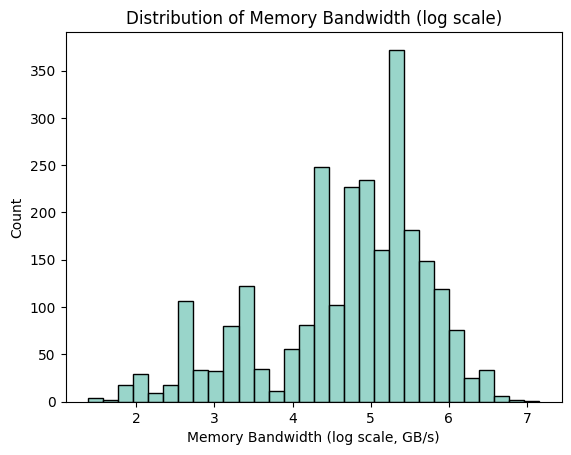

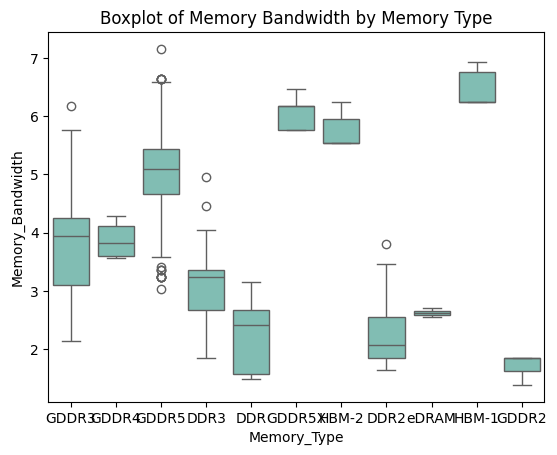

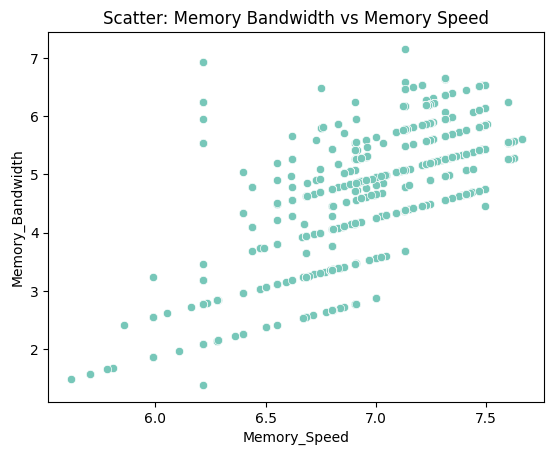

In [10]:
sns.histplot(main_data["Memory_Bandwidth"], bins=30, color="#77C7B9")
plt.title("Distribution of Memory Bandwidth (log scale)")
plt.xlabel("Memory Bandwidth (log scale, GB/s)")
plt.ylabel("Count")
plt.show()

sns.boxplot(x="Memory_Type", y="Memory_Bandwidth", data=main_data, color="#77C7B9")
plt.title("Boxplot of Memory Bandwidth by Memory Type")
plt.show()

sns.scatterplot(x="Memory_Speed", y="Memory_Bandwidth", data=main_data, color="#77C7B9")
plt.title("Scatter: Memory Bandwidth vs Memory Speed")
plt.show()

## 10. Train/test split

In [11]:
X = main_data[["Memory_Bus", "Memory_Speed", "ROPs", "Memory_Type_Numeric"]]
y = main_data["Memory_Bandwidth"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

## 11. Linear regression model

In [12]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred_linear = model.predict(X_test)

## 12. Statsmodels regression summary

In [13]:
X_train_const = sm.add_constant(X_train)
ols_model = sm.OLS(y_train, X_train_const).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:       Memory_Bandwidth   R-squared:                       0.921
Model:                            OLS   Adj. R-squared:                  0.921
Method:                 Least Squares   F-statistic:                     5244.
Date:                Thu, 12 Mar 2026   Prob (F-statistic):               0.00
Time:                        18:37:49   Log-Likelihood:                -343.37
No. Observations:                1800   AIC:                             696.7
Df Residuals:                    1795   BIC:                             724.2
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -7.6193    

## 13. Evaluation

In [14]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2 = r2_score(y_test, y_pred_linear)
print(f"RMSE: {rmse}")
print(f"R-squared: {r2}")

RMSE: 0.2717881540476916
R-squared: 0.9273096734616258


## 14. Ridge regularization

In [15]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

print(f"Ridge RMSE: {rmse_ridge}")
print(f"Ridge R-squared: {r2_ridge}")

Ridge RMSE: 0.2718195944040035
Ridge R-squared: 0.9272928549070241


## 15. Random Forest to detect non-linear relationship

In [16]:
# Train Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)

# Evaluation
rf_mse = mean_squared_error(y_test, y_pred_rf)
rf_r2 = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MSE:", rf_mse)
print("R2 Score:", rf_r2)

Random Forest Results
MSE: 0.00899383084218561
R2 Score: 0.9911496532402669


## 16. Cross Validation to compare models

In [20]:
# 5-fold cross validation
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Define models
models = {
    "Basic Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    
    "Ridge Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ]),
    
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        random_state=42
    )
}

# Store results
results = []

for name, model in models.items():
    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring={
            "r2": "r2",
            "mse": "neg_mean_squared_error"
        },
        return_train_score=False
    )
    
    mean_r2 = np.mean(scores["test_r2"])
    std_r2 = np.std(scores["test_r2"])
    mean_mse = -np.mean(scores["test_mse"])
    std_mse = np.std(-scores["test_mse"])
    
    results.append({
        "Model": name,
        "Mean R2": mean_r2,
        "Std R2": std_r2,
        "Mean MSE": mean_mse,
        "Std MSE": std_mse
    })

# Display comparison table
results_df = pd.DataFrame(results).sort_values(by="Mean R2", ascending=False)
results_df.style.format({
    "Mean R2": "{:.4f}",
    "Std R2": "{:.4f}",
    "Mean MSE": "{:.4f}",
    "Std MSE": "{:.4f}"
})
print(results_df)

                     Model   Mean R2    Std R2  Mean MSE   Std MSE
2            Random Forest  0.992715  0.001377  0.007849  0.002008
1  Ridge Linear Regression  0.922343  0.003794  0.082613  0.005118
0  Basic Linear Regression  0.922342  0.003803  0.082614  0.005112
